In [18]:
from tensorflow.keras import layers, models, applications
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [19]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [20]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# **1. Load the ResNet50 base without the top classification layer**
The ResNet50 was originally designed for the ImageNet dataset- by doing



include_top=False, we remove the 1000 classes classification layer, and use only the feature extraction part

weights = None: we are not using the pre-trained knowledge, but forcing the ResNet model to learn using only our Cifar10 dataset



In [22]:
# We use 'None' for weights if training from scratch, or 'imagenet' for pre-trained
base_model = applications.ResNet50(
    include_top=False,
    weights=None,
    input_shape=(32, 32, 3)
)

# 2. The Custom Classification Head

In [23]:
resnet_model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [24]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

training_set = train_datagen.flow(x_train, y_train, batch_size=64)

In [26]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow(x_test, y_test, batch_size=64)

In [27]:
# We flow the entire dataset (100%) through the generator
training_set_full = train_datagen.flow(x_train, y_train, batch_size=64)

print("--- Starting Full Dataset Training for ResNet50 ---")

# We train for the same number of epochs as the vanilla CNN for consistency
history_resnet_full = resnet_model.fit(
    training_set_full,
    epochs=50,
    validation_data=(x_test / 255.0, y_test),
    verbose=1
)

--- Starting Full Dataset Training for ResNet50 ---
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 126s 94ms/step - accuracy: 0.3182 - loss: 2.0907 - val_accuracy: 0.3469 - val_loss: 1.8967
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.4124 - loss: 1.6388 - val_accuracy: 0.4037 - val_loss: 1.6195
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.4261 - loss: 1.6145 - val_accuracy: 0.4470 - val_loss: 1.5269
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.4316 - loss: 1.5945 - val_accuracy: 0.3560 - val_loss: 1.8546
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 63ms/step - accuracy: 0.4716 - loss: 1.4908 - val_accuracy: 0.3717 - val_loss: 1.8895
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.4388 - loss: 1.5695 - val_accuracy: 0.2792 - val_loss: 2.1627
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.4460 - loss: 1.5497 - val_accuracy: 0.3945 - val_loss: 1.9870
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━

In [28]:
# 1. Evaluate on the Test Set
test_loss, test_acc = resnet_model.evaluate(test_set, verbose=1)

print(f"\n{'='*30}")
print(f"RESNET TEST RESULTS")
print(f"{'='*30}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7424 - loss: 0.7596

RESNET TEST RESULTS
Test Accuracy: 0.7424
Test Loss:     0.7596


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step


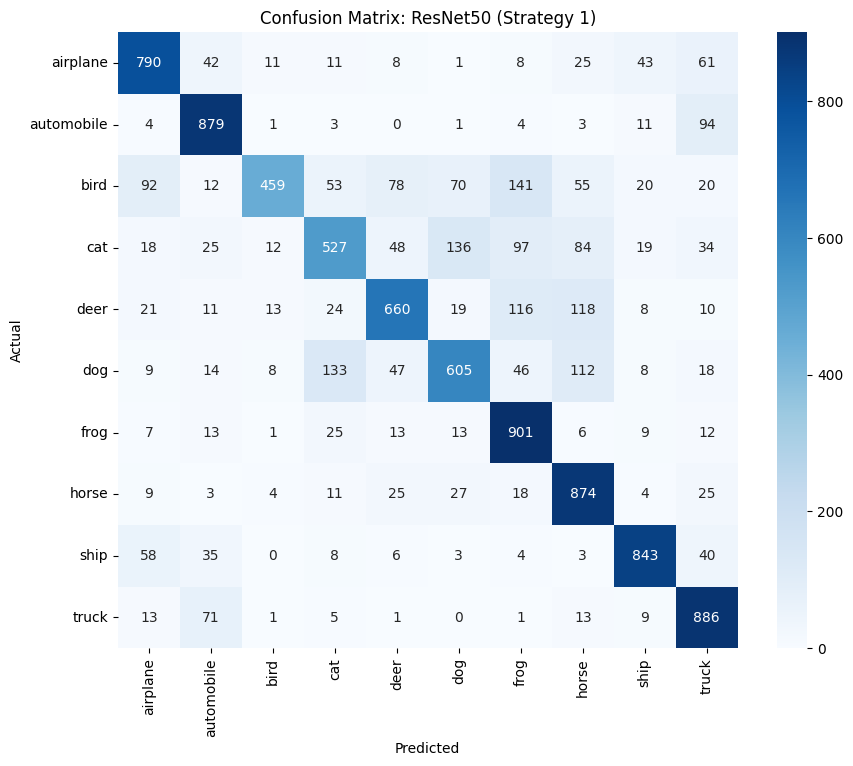

In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get all images and labels from the test set
# Note: We use the raw x_test (scaled) to ensure we get 1-to-1 mapping
x_test_scaled = x_test.astype('float32') / 255.0
y_pred_probs = resnet_model.predict(x_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Generate Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: ResNet50 (Strategy 1)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

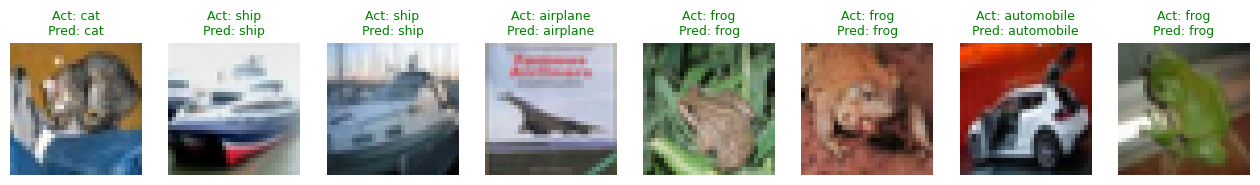

In [31]:
def plot_actual_vs_predicted(images, labels, predictions, class_names, n=8):
    plt.figure(figsize=(16, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i])

        actual = class_names[labels[i]]
        pred = class_names[predictions[i]]
        color = 'green' if actual == pred else 'red'

        plt.title(f"Act: {actual}\nPred: {pred}", color=color, fontsize=9)
        plt.axis('off')
    plt.show()

# Visualize the first 8 images of the test set
plot_actual_vs_predicted(x_test, y_true, y_pred_classes, class_names)

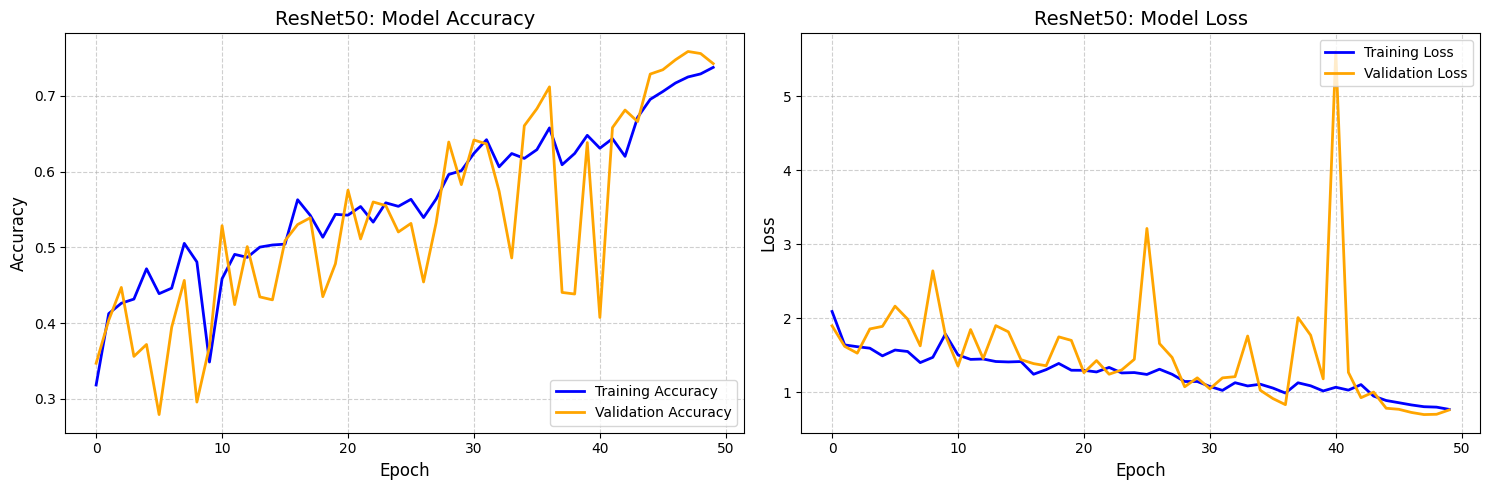

In [33]:
import matplotlib.pyplot as plt

def plot_resnet_results(history):
    # Set up the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Plot 1: Accuracy ---
    ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    ax1.set_title('ResNet50: Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Plot 2: Loss ---
    ax2.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    ax2.set_title('ResNet50: Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Execute the plotting function
plot_resnet_results(history_resnet_full)